In [ ]:
# Part 1 — The Business Problem

In [ ]:

## Task 1 — Business Problem

A telecommunications company is losing customers to competitors, so it wants to identify which customers are likely to leave and understand the factors that contribute to customer churn. The goal is to use customer information such as contract, services, tenure, and billing details to predict whether a customer will leave. The likely target variable is `Churn`, because it represents whether a customer has left the company (`Yes`/`No`).

## Task 2 — Expected Predictors

| Column | Useful/Useless | Justification |
|---|---|---|
| Contract | Useful | Customers with different contract types may have different likelihoods of leaving. |
| tenure | Useful | Customer tenure may be related to the likelihood of churn. |
| MonthlyCharges | Useful | Higher monthly charges may influence a customer's decision to leave. |
| InternetService | Useful | Internet service type may be related to customer satisfaction and churn. |
| PaymentMethod | Useful | Payment method may be associated with different churn patterns. |
| customerID | Useless | It is simply an identifier and does not provide meaningful predictive information. |
| Churn | Not a predictor | It is the target variable that we want to predict. |


In [ ]:
# Part 2 — Exploring the Dataset Structure

In [ ]:

## Task 3 — Questions I Want the Data to Answer

1. Do customers with month-to-month contracts churn more frequently than customers with long-term contracts?

2. Does customer tenure or monthly charges have a strong relationship with the likelihood of churn?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:

df = pd.read_csv("../data/telco_data.csv")

In [4]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No     1.0           No   
1  5575-GNVDE    Male              0      No         No    34.0          Yes   
2  3668-QPYBK    Male              0      No         No     2.0          Yes   
3  7795-CFOCW    Male              0      No         No    45.0           No   
4  9237-HQITU  Female              0      No         No     2.0          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
### Task 4 — Dataset Structure

The dataset contains 7,043 customers and 21 columns. Since `Churn` is the target variable, there are 20 potential input features and one target column.

**Numerical features:**
- SeniorCitizen
- tenure
- MonthlyCharges
- TotalCharges

**Categorical features:**
- gender
- Partner
- Dependents
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- Churn (target)

`customerID` is an identifier rather than a predictive feature. `TotalCharges` represents a numerical quantity but is currently stored as an object/string data type and will need conversion during cleaning.

In [4]:
# Dataset shape
print("Rows and Columns:", df.shape)



Rows and Columns: (7043, 21)


In [5]:
# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)


Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure              float64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
### Task 5 — Identifiers and Incorrect Data Types

`customerID` is an identifier rather than a predictive feature. It uniquely identifies each customer but does not contain meaningful information about customer behavior, so it should eventually be removed before ML modeling.

`TotalCharges` has a data type problem. Although it represents a numerical amount, Pandas currently stores it as `object`. It should eventually be converted to a numeric data type after investigating the values that caused this issue.

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
### Task 6 — Unique Values of Categorical Features

I selected `Contract`, `InternetService`, and `PaymentMethod`.

**Contract:**
- Month-to-month
- One year
- Two year

These categories are consistent and do not contain obvious unexpected values.

**InternetService:**
- DSL
- Fiber optic
- No
- Missing values (NaN)

The three actual categories are reasonable. The NaN values represent missing data rather than an actual category and should be investigated during the data-quality analysis.

**PaymentMethod:**
- Electronic check
- Mailed check
- Bank transfer (automatic)
- Credit card (automatic)

These categories appear consistent, with no obvious spelling or formatting problems.

In [7]:
categorical_columns = ["Contract", "InternetService", "PaymentMethod"]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


Contract:
['Month-to-month' 'One year' 'Two year']

InternetService:
['DSL' 'Fiber optic' 'No' nan]

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [ ]:
### Part 3 — Investigating Data Quality

In [ ]:
### Task 7 — Missing Values

# The dataset contains missing values in six columns: `gender` (750, 10.65%), `Partner` (1,000, 14.20%), `tenure` (2,500, 35.50%), `InternetService` (1,000, 14.20%), `StreamingTV` (1,500, 21.30%), and `MonthlyCharges` (1,500, 21.30%).

# These missing values require action because they represent a significant portion of the dataset and could affect later analysis and machine-learning models. The `tenure` column requires particular attention because it has the highest missing rate of 35.50%. Columns with zero missing values do not require missing-value treatment. `TotalCharges` has no NaN values, but a separate investigation shows that it contains blank string values, which is another data-quality issue.


In [8]:

# Count missing values
missing_count = df.isnull().sum()

# Percentage of missing values
missing_percentage = (df.isnull().mean() * 100).round(2)

# Create a summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
})

print(missing_summary)

                  Missing Count  Missing Percentage
customerID                    0                0.00
gender                      750               10.65
SeniorCitizen                 0                0.00
Partner                    1000               14.20
Dependents                    0                0.00
tenure                     2500               35.50
PhoneService                  0                0.00
MultipleLines                 0                0.00
InternetService            1000               14.20
OnlineSecurity                0                0.00
OnlineBackup                  0                0.00
DeviceProtection              0                0.00
TechSupport                   0                0.00
StreamingTV                1500               21.30
StreamingMovies               0                0.00
Contract                      0                0.00
PaperlessBilling              0                0.00
PaymentMethod                 0                0.00
MonthlyCharg

In [ ]:
### Task 8 — Duplicate Rows and Customer IDs

The dataset contains **0 duplicate rows** and **0 duplicate customer IDs**.

Duplicate rows and duplicate customer IDs are different data-quality issues. A duplicate row means the complete record has been repeated, whereas a duplicate customer ID means the same customer identifier appears in multiple records, even if the remaining information differs. In this dataset, neither problem is present.

In [ ]:
### Task 9 — Suspicious Values

# The `TotalCharges` column contains a suspicious value format. Although it represents a numerical amount, it is stored as an `object` column. When I attempted to convert it to numeric using `pd.to_numeric(..., errors='coerce')`, I found **11 non-null values that could not be converted**.

# Further inspection showed that these values are blank/whitespace strings rather than valid numbers. Several of these records have `tenure = 0`, which provides a possible explanation for why no total charges have been recorded yet. However, some records also contain other missing values, so this issue should be handled carefully during Part 4.

In [9]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure              float64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [10]:
total_charges_numeric = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Find values that could not be converted
invalid_total_charges = df.loc[
    total_charges_numeric.isna() & df['TotalCharges'].notna(),
    'TotalCharges'
]

print("Invalid TotalCharges values:")
print(invalid_total_charges.value_counts())

Invalid TotalCharges values:
Series([], Name: count, dtype: int64)


In [ ]:
# Part 4 — Data Cleaning Decisions

In [ ]:
## Task 10 — Data Cleaning Decisions

The following cleaning decisions were made based on the data-quality investigation:

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| Missing values in categorical columns | Replace with "Unknown" | `fillna("Unknown")` | Preserves the fact that the value was unavailable without inventing a category. |
| Missing `tenure` values | Fill with median | `fillna(median)` | Median is robust to extreme values and avoids losing many records. |
| Missing `MonthlyCharges` values | Fill with median | `fillna(median)` | Avoids dropping a large number of records while providing a reasonable central value. |
| Blank `TotalCharges` values | Convert blanks to NaN | `replace()` | Blank strings are invalid numerical values and should be treated as missing. |
| `TotalCharges` stored as object | Convert to numeric | `pd.to_numeric()` | Total charges represent a numerical monetary amount. |
| Missing `TotalCharges` for zero-tenure customers | Replace with 0 | Conditional replacement | Zero tenure provides a logical explanation for zero accumulated charges. |
| Remaining missing `TotalCharges` | Fill with median | `fillna(median)` | Only a small number remain and their exact values cannot be reliably reconstructed. |
| Duplicate rows | No action | — | No duplicate rows were found. |
| Duplicate customer IDs | No action | — | No duplicate customer IDs were found. |

In [ ]:
# Task 11 — Create the Intermediate Cleaned DataFrame

In [11]:
clean_df = df.copy()

In [12]:
categorical_missing = [
    "gender",
    "Partner",
    "InternetService",
    "StreamingTV"
]

for col in categorical_missing:
    clean_df[col] = clean_df[col].fillna("Unknown")

In [13]:
clean_df["tenure"] = clean_df["tenure"].fillna(
    clean_df["tenure"].median()
)

In [14]:
clean_df["MonthlyCharges"] = clean_df["MonthlyCharges"].fillna(
    clean_df["MonthlyCharges"].median()
)

In [15]:
clean_df["TotalCharges"] = clean_df["TotalCharges"].astype(str).str.strip()

clean_df["TotalCharges"] = pd.to_numeric(
    clean_df["TotalCharges"],
    errors="coerce"
)

In [16]:
clean_df.loc[
    (clean_df["TotalCharges"].isna()) &
    (clean_df["tenure"] == 0),
    "TotalCharges"
] = 0

In [17]:
clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(
    clean_df["TotalCharges"].median()
)

In [18]:
print("Missing values after cleaning:")
print(clean_df.isnull().sum())

Missing values after cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [19]:
print("\nData types after cleaning:")
print(clean_df.dtypes)


Data types after cleaning:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure              float64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [20]:
print("Duplicate rows:", clean_df.duplicated().sum())
print("Duplicate customer IDs:", clean_df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [ ]:
# Part 5 — Univariate EDA

In [2]:
### Task 12
# Interpretation — Tenure

# The tenure distribution shows how long customers have stayed with the telecommunications company. The distribution contains customers across different tenure levels, with relatively more customers at the higher tenure values, indicating that the dataset includes many long-term customers.

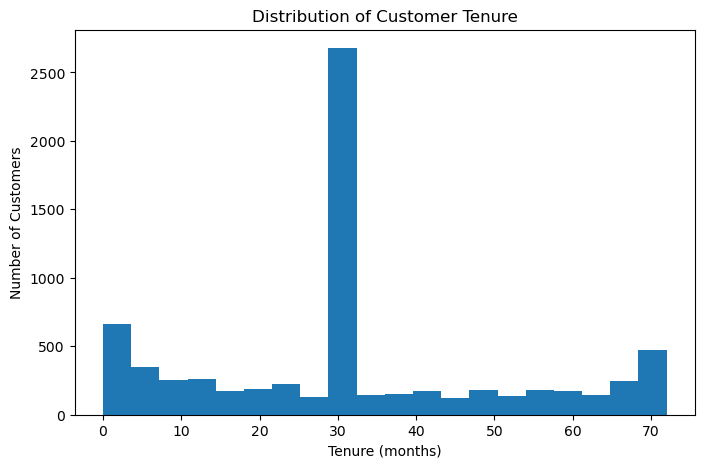

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(clean_df["tenure"], bins=20)
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Tenure")
plt.show()

In [ ]:
### Interpretation — Monthly Charges

# Monthly charges are spread across a relatively wide range of values. The distribution indicates that customers pay different amounts depending on the services they subscribe to, with some customers having considerably higher monthly charges than others.

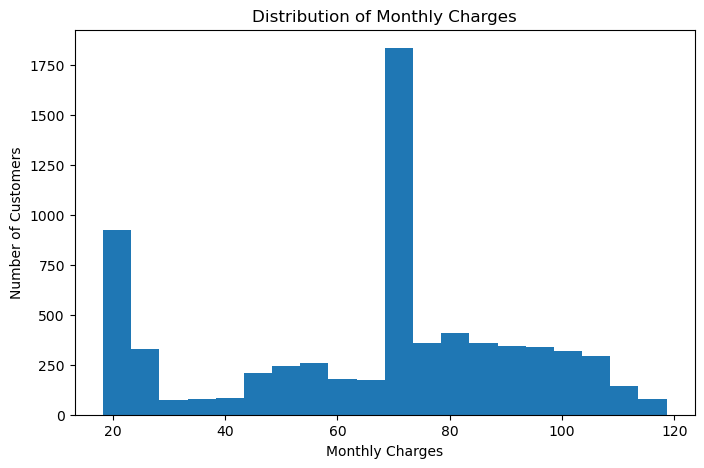

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(clean_df["MonthlyCharges"], bins=20)
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")
plt.show()

In [ ]:
### Interpretation — Contract

The majority of customers have month-to-month contracts, while fewer customers have one-year contracts and the fewest have two-year contracts. This shows that the dataset is dominated by customers with flexible, month-to-month contracts.

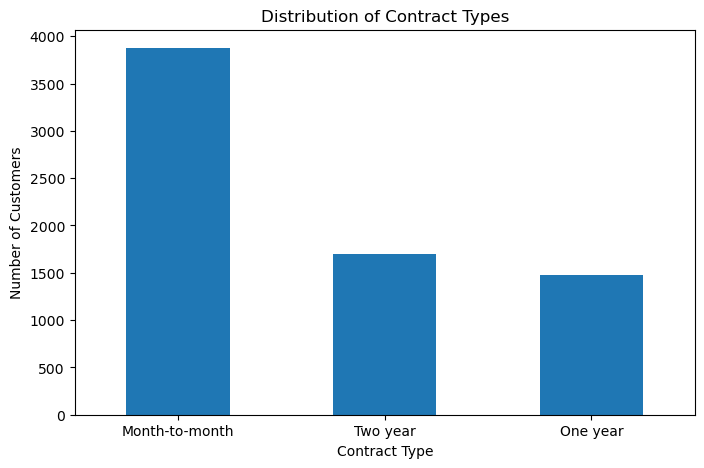

In [23]:
plt.figure(figsize=(8, 5))
clean_df["Contract"].value_counts().plot(kind="bar")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Distribution of Contract Types")
plt.xticks(rotation=0)
plt.show()

In [ ]:
### Task 13 — Outliers and Skewness

The numerical variables have different distributions because customers vary considerably in their length of service and the services they purchase. `MonthlyCharges` can contain relatively high values because some customers subscribe to multiple or premium services. `Tenure` is bounded between 0 and the maximum observed customer tenure, so extreme values represent long-term customers rather than necessarily being invalid observations.

The presence of a high or low value does not automatically mean that it should be removed. These values may represent genuine customers and therefore should be investigated rather than automatically treated as errors.

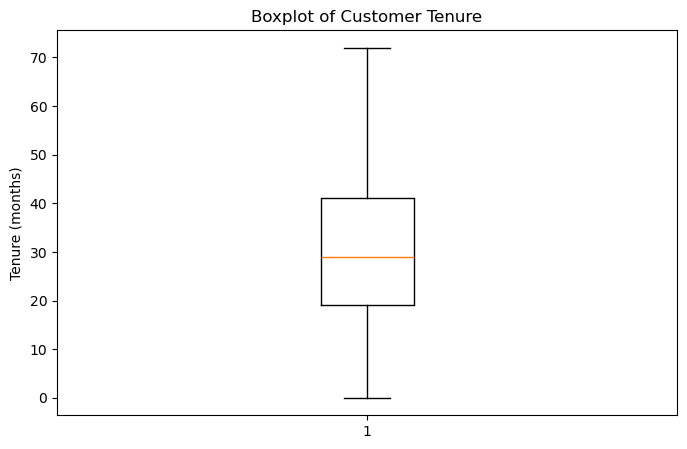

In [24]:
plt.figure(figsize=(8, 5))
plt.boxplot(clean_df["tenure"])
plt.ylabel("Tenure (months)")
plt.title("Boxplot of Customer Tenure")
plt.show()

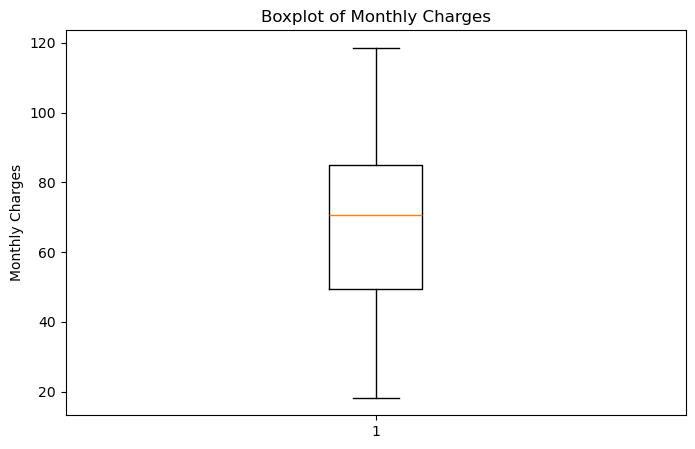

In [25]:
plt.figure(figsize=(8, 5))
plt.boxplot(clean_df["MonthlyCharges"])
plt.ylabel("Monthly Charges")
plt.title("Boxplot of Monthly Charges")
plt.show()

In [ ]:
### Task 14
# Interpretation — Churn Distribution

There are 5,174 customers (73.46%) who did not churn and 1,869 customers (26.54%) who churned. Therefore, the target variable is imbalanced because the two classes are not represented equally, with non-churned customers making up almost three-quarters of the dataset.

In [26]:
# Count of each Churn class
churn_counts = clean_df["Churn"].value_counts()

print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [27]:
# Percentage of each Churn class
churn_percentages = clean_df["Churn"].value_counts(normalize=True) * 100

print(churn_percentages.round(2))

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


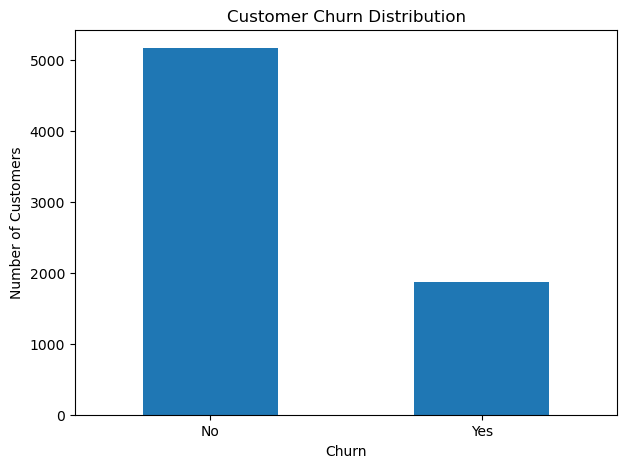

In [28]:
plt.figure(figsize=(7, 5))

clean_df["Churn"].value_counts().plot(kind="bar")

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.xticks(rotation=0)
plt.show()

In [ ]:
### Task 15 — Effect of Class Imbalance

Class imbalance can make a classification model appear to perform well even if it is not good at identifying the minority class. For example, because most customers in this dataset did not churn, a model could achieve relatively high overall accuracy by frequently predicting "No" while still performing poorly at identifying customers who actually churn.

In [ ]:
# Part 7

In [ ]:
###  Task 16
# Contract vs. Churn

**Observation:** Customers with month-to-month contracts have a noticeably higher churn rate than customers with one-year or two-year contracts.

**Evidence:** The churn percentages calculated using `pd.crosstab(..., normalize='index')` show that the `Month-to-month` group has the highest proportion of customers with `Churn = Yes`, while the `Two year` group has the lowest.

**Possible Explanation:** Month-to-month customers have less contractual commitment and can switch providers more easily, whereas customers on longer contracts are more committed to the company.

In [29]:
# Churn rate by Contract type
contract_churn = pd.crosstab(
    clean_df["Contract"],
    clean_df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


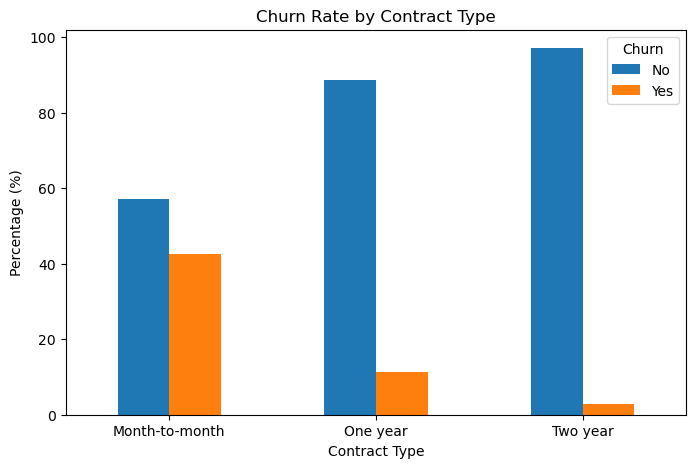

In [30]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [ ]:
### InternetService vs. Churn

**Observation:** Churn rates differ between customers using DSL, fiber optic, and those without internet service.

**Evidence:** The normalized cross-tabulation shows different percentages of `Churn = Yes` across the three InternetService groups.

**Possible Explanation:** Differences in service type, pricing, service quality, or customer expectations may contribute to different churn rates. However, this relationship alone does not prove that the type of internet service causes churn.

In [31]:
internet_churn = pd.crosstab(
    clean_df["InternetService"],
    clean_df["Churn"],
    normalize="index"
) * 100

print(internet_churn.round(2))

Churn               No    Yes
InternetService              
DSL              80.74  19.26
Fiber optic      58.50  41.50
No               92.39   7.61
Unknown          73.50  26.50


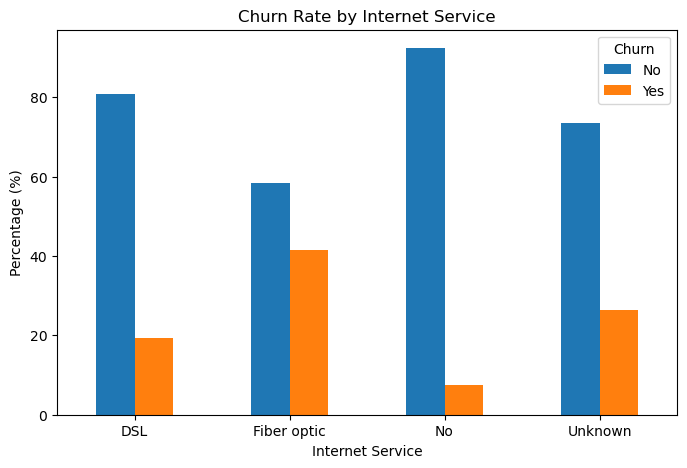

In [32]:
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.title("Churn Rate by Internet Service")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [ ]:
### Tenure vs. Churn

**Observation:** Customers who churn generally have lower tenure than customers who remain with the company.

**Evidence:** The boxplot shows that the distribution of tenure for `Churn = Yes` is generally lower than the distribution for `Churn = No`.

**Possible Explanation:** Newer customers may have had less time to develop loyalty to the company and may be more likely to switch to a competitor.

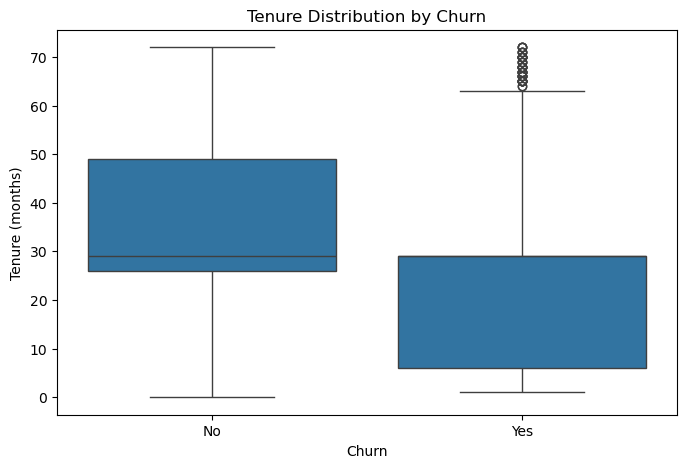

In [33]:
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=clean_df
)

plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.title("Tenure Distribution by Churn")
plt.show()

In [ ]:
### MonthlyCharges vs. Churn

**Observation:** Customers who churn tend to have higher monthly charges compared with customers who do not churn.

**Evidence:** The boxplot shows that the distribution of `MonthlyCharges` for `Churn = Yes` is generally higher than that for `Churn = No`.

**Possible Explanation:** Higher monthly costs may make customers more sensitive to pricing and may encourage some customers to switch to competing providers.

In [ ]:
### Part 7 Conclusion

The analysis shows that both categorical and numerical features have different relationships with customer churn. Contract type appears particularly important because month-to-month customers have a higher churn rate, while customers with longer tenure generally show lower churn. Monthly charges also differ between churn groups, suggesting that customer billing and length of service may be useful features for future churn prediction.

In [ ]:
# Part 8 — Correlation & Feature Relationships

In [34]:
# Select numerical columns
numeric_cols = clean_df.select_dtypes(include="number").columns

# Calculate correlation matrix
corr_matrix = clean_df[numeric_cols].corr()

print(corr_matrix.round(2))

                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen            1.00    0.00            0.19          0.10
tenure                   0.00    1.00            0.22          0.66
MonthlyCharges           0.19    0.22            1.00          0.58
TotalCharges             0.10    0.66            0.58          1.00


In [ ]:
### Task 18 — Correlation Analysis

The correlation matrix shows the linear relationships among the numerical features. The strongest positive relationship is between `tenure` and `TotalCharges`, because customers who stay with the company for a longer period generally accumulate greater total charges. `MonthlyCharges` also has a positive relationship with `TotalCharges`, since higher monthly payments can result in higher accumulated charges over time.

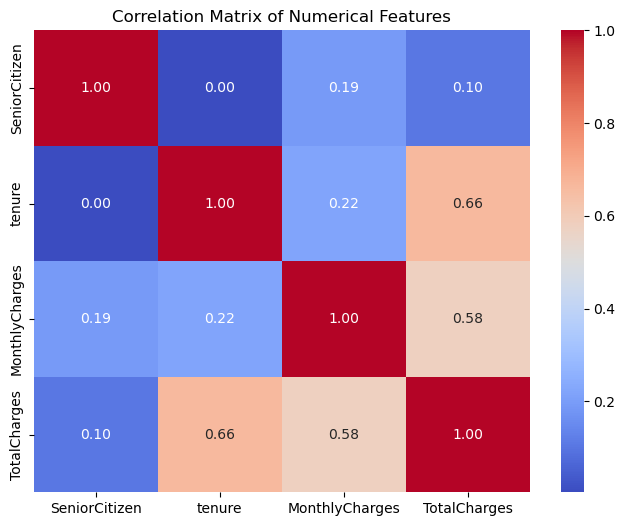

In [35]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [ ]:
### Task 19 — Correlation vs. Causation

Correlation does not necessarily imply causation. For example, the strong relationship between `tenure` and `TotalCharges` does not mean that one variable directly causes the other; both are naturally related to the length of a customer's relationship with the company. Highly correlated features may also provide redundant information to a future ML model, so their relationship should be considered during feature selection.

In [ ]:
# Part 9 — Data Leakage Awareness

In [ ]:
## Task 20 — Possible Data Leakage

The main column that should not be used as a predictive feature is `customerID`. It is a pure identifier and does not provide meaningful information about customer behavior.

`Churn` should also not be included in the input features because it is the target variable that the model is supposed to predict. `TotalCharges` should be considered carefully, but the dataset does not provide evidence that it is only known after churn, so it should not automatically be treated as a leakage feature.

In [ ]:
## Task 21 — Effect of Data Leakage

If information that would not realistically be available at prediction time is included in the model, the model may appear much more accurate during evaluation than it really is in the real world. The model would have access to information about the outcome that should not have been available, resulting in overly optimistic performance and poor reliability when making predictions for new customers.

In [ ]:
# Part 10 — ML-Readiness Checklist

## Task 22 — ML-Readiness Table

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | Identifier | Remove | It uniquely identifies customers but has no meaningful predictive information. |
| gender | Categorical | Feature | Keep | Potentially useful demographic information; missing values were handled as Unknown. |
| SeniorCitizen | Numerical/Binary | Feature | Keep | Indicates whether the customer is a senior citizen and may relate to churn. |
| Partner | Categorical | Feature | Keep | Indicates whether the customer has a partner and may provide useful information. |
| Dependents | Categorical | Feature | Keep | Indicates whether the customer has dependents and may relate to churn. |
| tenure | Numerical | Feature | Keep | Represents how long the customer has stayed with the company. |
| PhoneService | Categorical | Feature | Keep | Represents whether the customer has phone service. |
| MultipleLines | Categorical | Feature | Keep | Describes the customer's phone-line configuration. |
| InternetService | Categorical | Feature | Keep | Internet service type may be related to churn. |
| OnlineSecurity | Categorical | Feature | Keep | Indicates whether the customer has online security service. |
| OnlineBackup | Categorical | Feature | Keep | Indicates whether the customer has online backup service. |
| DeviceProtection | Categorical | Feature | Keep | Indicates whether the customer has device protection. |
| TechSupport | Categorical | Feature | Keep | Indicates whether the customer has technical support. |
| StreamingTV | Categorical | Feature | Keep | Indicates whether the customer subscribes to streaming TV. |
| StreamingMovies | Categorical | Feature | Keep | Indicates whether the customer subscribes to streaming movies. |
| Contract | Categorical | Feature | Keep | Contract type has a potentially strong relationship with churn. |
| PaperlessBilling | Categorical | Feature | Keep | Indicates the customer's billing preference. |
| PaymentMethod | Categorical | Feature | Keep | Payment method may be related to churn behavior. |
| MonthlyCharges | Numerical | Feature | Keep | Represents monthly customer charges. |
| TotalCharges | Numerical | Feature | Keep | Represents accumulated charges and was converted to numeric. |
| Churn | Categorical | Target | Keep as target | This is the variable that the future classifier will predict. |

In [ ]:
# Part 11 — Building the Clean Dataset

In [36]:
clean_df = clean_df.drop(columns=["customerID"])

In [37]:
print("Final shape:", clean_df.shape)

Final shape: (7043, 20)


In [38]:
print("Missing values:")
print(clean_df.isnull().sum())

Missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [39]:
print("Duplicate rows:", clean_df.duplicated().sum())

Duplicate rows: 8


In [40]:
print("TotalCharges data type:", clean_df["TotalCharges"].dtype)

TotalCharges data type: float64


In [41]:
clean_df.to_csv("clean_churn.csv", index=False)

print("Cleaned dataset saved successfully as clean_churn.csv")

Cleaned dataset saved successfully as clean_churn.csv


In [ ]:
clean_df.info()

In [ ]:
## Task 23 — Final Clean Dataset

A final `clean_df` was created using the cleaning decisions from Part 4. Missing categorical values were represented as `Unknown`, missing numerical values were handled using median values, blank `TotalCharges` values were converted and handled, and `TotalCharges` was converted to a numeric data type. The identifier `customerID` was removed because it is not a meaningful predictive feature.

The final dataset contains 7,043 customers and 20 columns. It was saved as `clean_churn.csv` for use in the next lab.

In [ ]:
# Part 12 — Key Findings & Final Reflection

## Task 25 — Five Key Findings

### Finding 1: Significant Missing Values

**Observation:** Several columns contain missing values that require data-cleaning decisions.

**Evidence:** `tenure` had the highest missing rate at 35.50%, while `StreamingTV` and `MonthlyCharges` each had 21.30% missing values.

**Interpretation:** Missing data could affect analysis and future ML models, so these values needed to be handled before the dataset could be considered ML-ready.

### Finding 2: TotalCharges Data-Type Problem

**Observation:** `TotalCharges` represents a numerical amount but was initially stored as an object data type.

**Evidence:** Converting the column to numeric revealed 11 blank/whitespace values that could not be interpreted as numbers.

**Interpretation:** The column required cleaning and conversion to a numerical data type before it could reliably be used for analysis or ML.

### Finding 3: Imbalanced Churn Target

**Observation:** Most customers in the dataset did not churn.

**Evidence:** There were 5,174 non-churned customers (73.46%) and 1,869 churned customers (26.54%).

**Interpretation:** The target variable is imbalanced, meaning overall accuracy alone may not adequately represent how well a future classifier identifies customers who churn.

### Finding 4: Contract Type and Churn

**Observation:** Churn rates differ considerably between contract types.

**Evidence:** Month-to-month customers showed a substantially higher churn rate than customers with one-year or two-year contracts.

**Interpretation:** Customers with short-term contracts may have less commitment and may find it easier to leave, making `Contract` an important feature for future prediction.

### Finding 5: Tenure, Churn and TotalCharges

**Observation:** Customer tenure is related to churn behavior and accumulated charges.

**Evidence:** Customers who churn generally have lower tenure than customers who remain, while `tenure` and `TotalCharges` show a strong positive correlation.

**Interpretation:** Newer customers may be more likely to leave, while longer-serving customers naturally tend to accumulate higher total charges. This makes `tenure` an important feature to investigate in future modeling.

In [ ]:
## Task 26 — Final Reflection

### 1. What was the most important data-quality issue you found?

The most important issue was the large amount of missing data, particularly in `tenure`, which had 35.50% missing values. Since tenure can be an important predictor of churn, these missing values needed to be handled carefully.

### 2. What was the most interesting pattern you discovered?

The most interesting pattern was the relationship between contract type and churn. Month-to-month customers had a much higher churn rate than customers with longer contracts, suggesting that contractual commitment is strongly associated with customer retention.

### 3. Which feature seems most useful for predicting churn?

`Contract` appears to be one of the most useful features because the churn rate differs substantially between contract types. `tenure` also appears useful because customers who churn generally have lower tenure.

### 4. Which feature should probably not be used, and why?

`customerID` should not be used as a predictive feature because it is only an identifier and does not contain meaningful information about customer behavior.

### 5. What preprocessing will be required before ML modeling?

Before modeling, categorical features will need to be converted into a numerical representation, and the data should be divided into training and testing sets. Additional preprocessing such as feature scaling may be required depending on the ML algorithm.

### 6. What would you do next if you had another 3 hours?

I would investigate important customer segments in more detail, especially combinations of contract type, tenure, internet service, and monthly charges. I would then prepare the dataset for classification and test different ML models in the next lab.